<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/LANL-logo.png" alt="LANL Logo" style="width: 200px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/prowess.png" alt="Prowess Logo" style="width: 200px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wildfire.png" alt="WildFire Logo" width="100"/>
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">Fire-Ready Forests Data Challenge</h1>

# Sprint 1 - Tasks 5-6

**Team Name: Heatmappers** 

**Members:**

- Ansh Bhatnagar
- Jiahe Qin
- Jeronimo Adames-Baena
- Ishayu Ghosh

Use this notebook to report your solutions for tasks 5-6 of Sprint 1. Add code and markdown cells as needed to report your solutions.

### Task 5

Following the lidar point cloud module as a guide, select one ALS scan and one TLS scan from Independence Lake. Describe the differences in the two datasets (e.g. extent, number of points, resolutions) and include at least 2 figures in the response.

To correctly associate each LiDAR file with its respective location, use the Plot Identification file inside each dataset. This file provides information about each plot, linking scans file names to specific areas.

--2025-04-13 22:14:40--  https://wifire-data.sdsc.edu/nc/s/nnSMqWfZAN6Cz6m/download?path=%2Fnew_data%2FRaw%20ALS%20and%20Detected%20Trees%2FALS%20data&files=USGS_LPC_CA_SierraNevada_B22_10SGJ3070.laz&downloadStartSecret=aik5h9wexsu
Resolving wifire-data.sdsc.edu (wifire-data.sdsc.edu)... 198.202.90.208
Connecting to wifire-data.sdsc.edu (wifire-data.sdsc.edu)|198.202.90.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 121593043 (116M) [application/octet-stream]
Saving to: ‘als_choice.laz’

als_choice.laz      100%[===================>] 115.96M  36.9MB/s    in 3.1s    

2025-04-13 22:14:44 (36.9 MB/s) - ‘als_choice.laz’ saved [121593043/121593043]

--2025-04-13 22:14:45--  https://wifire-data.sdsc.edu/nc/s/5oiFgzCdo4QPi34/download?path=%2FLidar_data&files=CAFKU_0141_20240718_1.ptx&downloadStartSecret=0dig3e5w9k1
Resolving wifire-data.sdsc.edu (wifire-data.sdsc.edu)... 198.202.90.208
Connecting to wifire-data.sdsc.edu (wifire-data.sdsc.edu)|198.202.90.208|:44

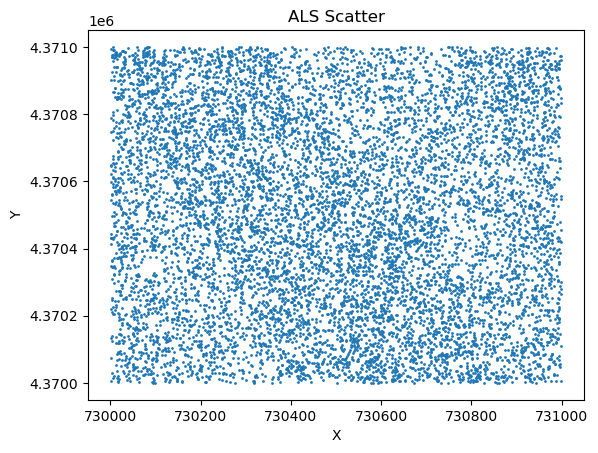

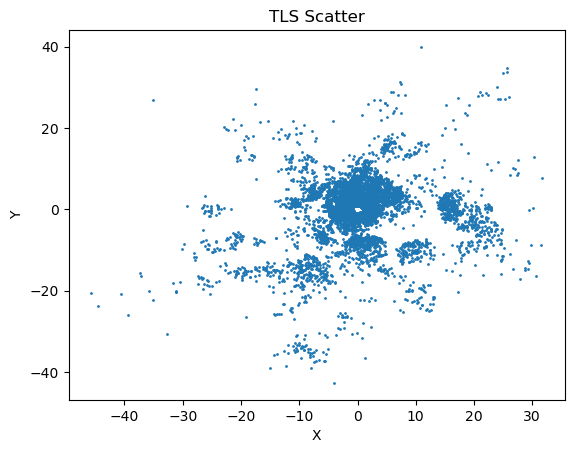

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pdal
import json
import laspy

#%%capture
!wget -O als_choice.laz "https://wifire-data.sdsc.edu/nc/s/nnSMqWfZAN6Cz6m/download?path=%2Fnew_data%2FRaw%20ALS%20and%20Detected%20Trees%2FALS%20data&files=USGS_LPC_CA_SierraNevada_B22_10SGJ3070.laz&downloadStartSecret=aik5h9wexsu"
#%%capture
!wget -O tls_choice.ptx "https://wifire-data.sdsc.edu/nc/s/5oiFgzCdo4QPi34/download?path=%2FLidar_data&files=CAFKU_0141_20240718_1.ptx&downloadStartSecret=0dig3e5w9k1"

als_file = "als_choice.laz"
tls_file = "tls_choice.ptx"

als_data = laspy.read(als_file)
print("ALS File:", als_file)
print("Number of ALS Points:", len(als_data.x))
print("X Range:", als_data.header.min[0], "to", als_data.header.max[0])
print("Y Range:", als_data.header.min[1], "to", als_data.header.max[1])
print("Z Range:", als_data.header.min[2], "to", als_data.header.max[2])

pipeline_cfg = {"pipeline": [{"type": "readers.ptx","filename": tls_file}]}
pipeline = pdal.Pipeline(json.dumps(pipeline_cfg))
pipeline.execute()
tls_arrays = pipeline.arrays
tls_points = tls_arrays[0]
print("\nTLS File:", tls_file)
print("Number of TLS Points:", len(tls_points))

als_subset = np.random.choice(len(als_data.x), size=min(10000, len(als_data.x)), replace=False)
als_x_sub = als_data.x[als_subset]
als_y_sub = als_data.y[als_subset]

plt.figure()
plt.scatter(als_x_sub, als_y_sub, s=1)
plt.title("ALS Scatter")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

tls_subset = np.random.choice(len(tls_points), size=min(10000, len(tls_points)), replace=False)
tls_x_sub = tls_points['X'][tls_subset]
tls_y_sub = tls_points['Y'][tls_subset]

plt.figure()
plt.scatter(tls_x_sub, tls_y_sub, s=1)
plt.title("TLS Scatter")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


From this, we can see how the ALS file als_choice.laz and the TLS file tls_choice.ptx from the Independence Lake dataset directly compare. The ALS scan covers a much wider area, with coordinates ranging from around 730000 to 731000 in the X direction and 4370000 to 4371000 in the Y direction. It contains about 2.7 million points total, which are relatively evenly distributed across the large region. The TLS file, on the other hand, captures a much smaller area, about 80 meters across in both X and Y, but with a much higher level of detail, holding around 8 million points in total. Looking at the figures, the ALS scatter plot shows a broad and fairly uniform spread of points across a large landscape. The TLS scatter on the other hand is tightly clustered and much denser, centered around the scan location. This intuitively makes sense since ALS is used for large scale mapping with moderate point density, while TLS focuses on smaller plots with high resolution, capturing finer details like individual tree structures or ground features. This ALS data uses a global coordinate system, which is why the coordinate values are large, while the TLS data appears to use a local coordinate system centered on zero. This difference in scale and resolution highlights how ALS and TLS are complementary and cohesive, with ALS providing a wide area overview and TLS offering a much more focused and detailed structural data in a smaller area.

### Task 6
So far, we have mainly been exploring how tabular data can be used to create models to predict DBH. However, we also have lidar data which can be used. Given what you have learned in the lidar point cloud module and other resources, describe some metrics that you could derive from the point cloud data as an extra input to your model.

**Your Response:** Lidar data, particularly from Terrestrial Laser Scanning (TLS), enables detailed analysis of forest structure, revealing the vertical distribution of tree canopy heights and distinct layers within the forest. TLS allows for precise classification distribution analysis, showcasing the proportions of different tree types or growth stages. Additionally, Airborne Laser Scanning (ALS) data facilitates estimations of tree density and area by analyzing the shape and spatial arrangement of sample points, providing broader contextual information. Integrating these insights, derived from both TLS and ALS, with tabular data enhances DBH prediction models by incorporating crucial structural and spatial characteristics.